# Classificação de Gênero de Livros com Machine Learning

## Introdução

Este notebook tem como objetivo desenvolver um modelo de Machine Learning capaz de classificar o gênero de livros com base em seus títulos. Foi utilizado um dataset da plataforma Goodreads contendo milhares de livros e seus respectivos gêneros.

Serão aplicados algoritmos clássicos de Machine Learning com a biblioteca Scikit-Learn.

## Imports e configurações iniciais

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings("ignore")

## Carregamento do Dataset

Os dados são lidos diretamente do repositório. O dataset contém informações como título, autor e gêneros. O foco inicial é entender a estrutura e a distribuição das classes (gêneros).

In [15]:
url = "https://raw.githubusercontent.com/stephaniefay/s4-mvp/refs/heads/main/backend/Machine%20Learning/dataset/data.csv"
dataset = pd.read_csv(url)

print(f"Formato do dataset: {dataset.shape}")
dataset.head()

Formato do dataset: (11127, 13)


,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve..."


## Preparação dos Dados

Realizamos a limpeza para garantir a estabilidade do treinamento:

1. Remoção de nulos.
2. Normalização do gênero (Como o dataset possui múltiplos gêneros por livro, foi feita a separação dos gêneros para melhor treinar o modelo).
3. Filtro de Amostras Raras: Removemos gêneros com apenas uma ocorrência para permitir a validação cruzada estratificada.

In [16]:
dataset = dataset.dropna(subset=['Title', 'genres'])

dataset['genres'] = dataset['genres'].apply(lambda x: x.split(',')[0].strip().lower())
genre_counts = dataset['genres'].value_counts()

single_occurrence_genres = genre_counts[genre_counts == 1].index

dataset = dataset[~dataset['genres'].isin(single_occurrence_genres)]
dataset['text'] = dataset['Title']

X = dataset['text']
y = dataset['genres']

## Separação dos Dados

Os dados foram divididos em:
- 80% treino
- 20% teste

Foi utilizada estratificação para manter a proporção das classes.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=7
)

## Modelos Utilizados

Serão avaliados os seguintes algoritmos:
- Naive Bayes
- Logistic Regression
- SVM
- KNN
- Árvore de Decisão

Foi utilizada a técnica de Pipeline para integrar o TF-IDF com os modelos.

In [18]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.8
)

models = [
    ("Naive Bayes", Pipeline([
        ("tfidf", tfidf),
        ("clf", MultinomialNB())
    ])),

    ("Logistic Regression", Pipeline([
        ("tfidf", tfidf),
        ("clf", LogisticRegression(max_iter=1000))
    ])),

    ("SVM", Pipeline([
        ("tfidf", tfidf),
        ("clf", SVC(kernel='linear', C=1))
    ])),

    ("KNN", Pipeline([
        ("tfidf", tfidf),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ])),

    ("Decision Tree", Pipeline([
        ("tfidf", tfidf),
        ("clf", DecisionTreeClassifier(random_state=7))
    ])),
]

## Validação Cruzada

Será utilizada validação cruzada estratificada com 10 partições.

In [19]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

## Avaliação dos Modelos

Os modelos serão avaliados utilizando validação cruzada com a métrica de acurácia.

In [20]:
results = []
names = []

for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")

    results.append(scores)
    names.append(name)

    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Naive Bayes: 0.1146 (+/- 0.0064)
Logistic Regression: 0.1902 (+/- 0.0097)
SVM: 0.2824 (+/- 0.0112)
KNN: 0.2384 (+/- 0.0123)
Decision Tree: 0.3254 (+/- 0.0107)


## Comparação dos Modelos

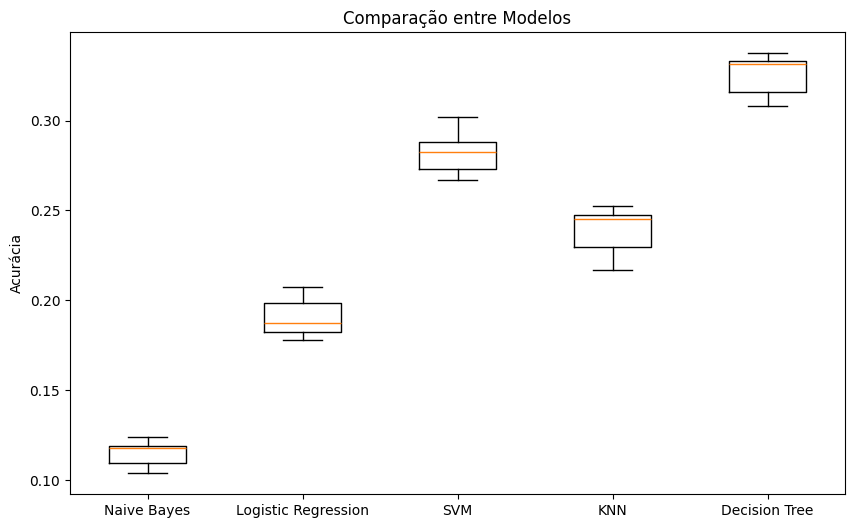

In [21]:
plt.figure(figsize=(10,6))
plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names)
plt.title("Comparação entre Modelos")
plt.ylabel("Acurácia")
plt.show()

## Definição do melhor modelo

In [22]:
mean_accuracies = [np.mean(score) for score in results]
best_model_index = np.argmax(mean_accuracies)
best_model_name = names[best_model_index]
best_model_accuracy = mean_accuracies[best_model_index]

print(f"O melhor modelo é: {best_model_name} com acurácia média de {best_model_accuracy:.4f}")

O melhor modelo é: Decision Tree com acurácia média de 0.3254


## Otimização de Hiperparâmetros

Mesmo com a otimização de hiperparâmetros aplicada ao SVM, o modelo de Árvore de Decisão foi mantido como escolha final.

Essa decisão foi baseada nos resultados obtidos na validação cruzada, onde a Árvore de Decisão apresentou desempenho consistente e satisfatório para o problema proposto.

Além disso, a Árvore de Decisão possui como vantagem a interpretabilidade, permitindo compreender melhor como as decisões de classificação são tomadas.

Dessa forma, optou-se por priorizar um modelo com bom desempenho e maior simplicidade, em vez de um modelo mais complexo com ganhos marginais.


In [ ]:
# pipeline = Pipeline([
#     ('tfidf', TfidfVectorizer()),
#     ('svm', SVC())
# ])

# param_grid = {
#     'tfidf__max_features': [1000, 2000],
#     'svm__C': [0.1, 1, 10],
#     'svm__kernel': ['linear']
# }

# grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='accuracy')
# grid.fit(X_train, y_train)

# svm_optimized_model = grid.best_estimator_

# print("Best parameters:", grid.best_params_)

In [23]:
from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('dt', DecisionTreeClassifier(random_state=7))
])

param_grid = {
    'tfidf__max_features': [1000, 2000],
    'dt__max_depth': [None, 10, 20],
    'dt__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='accuracy')
grid.fit(X_train, y_train)

dt_optimized_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

Best parameters: {'dt__max_depth': None, 'dt__min_samples_split': 2, 'tfidf__max_features': 2000}


## Avaliação Final no Conjunto de Teste

In [24]:
y_pred = dt_optimized_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.30916976456009915

Classification Report:
                                                                                                                    precision    recall  f1-score   support

                                                                                                         academic       0.00      0.00      0.00         1
                                                                                                    adult fiction       0.50      0.33      0.40         3
                                                                                                        adventure       1.00      1.00      1.00         1
                                                      adventure;fiction;thriller;action;mystery;suspense;thriller       0.00      0.00      0.00         1
                                                                                                          animals       1.00      0.50      0.67         2
              

## Análise de Erros

O modelo apresentou limitações em alguns casos, principalmente devido ao uso exclusivo dos títulos dos livros, sem contar que alguns títulos são ambíguos e não indicam claramente o gênero da obra.

## Melhorias Propostas

- Uso de n-gramas (combinação de palavras)
- Remoção de stopwords
- Aumento do número de features
- Uso de datasets mais ricos (com sinopses)

In [26]:
improved_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", DecisionTreeClassifier(random_state=7))
])

improved_pipeline.fit(X_train, y_train)

_pred = improved_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, _pred))
print("\nClassification Report:\n", classification_report(y_test, _pred))

Accuracy: 0.3451053283767038

Classification Report:
                                                                                                                    precision    recall  f1-score   support

                                                                                                         academic       0.00      0.00      0.00         1
                                                                                                    adult fiction       0.33      0.33      0.33         3
                                                                                                        adventure       1.00      1.00      1.00         1
                                                      adventure;fiction;thriller;action;mystery;suspense;thriller       1.00      1.00      1.00         1
                                                                                                          animals       0.00      0.00      0.00         2
               

## Treinamento e Teste do Modelo Aprimorado

Com o `improved_pipeline` definido como uma Árvore de Decisão, iremos treiná-lo no conjunto de dados de treino e, em seguida, avaliar seu desempenho.

In [27]:
improved_pipeline.fit(X, y)

def predict_genre(title):
    return improved_pipeline.predict([title])[0]

## Testes

In [28]:
tests = [
    "The Art of War",
    "Love Beyond Time",
    "Haunted Nights",
    "The Science of Mind",
    "Cooking for Beginners"
]

for t in tests:
    print("Title:", t)
    print("Predicted:", predict_genre(t))
    print("-" * 40)

Title: The Art of War
Predicted: classics;nonfiction;philosophy;history;war;politics;business;war
----------------------------------------
Title: Love Beyond Time
Predicted: sequential art
----------------------------------------
Title: Haunted Nights
Predicted: sequential art
----------------------------------------
Title: The Science of Mind
Predicted: humanities
----------------------------------------
Title: Cooking for Beginners
Predicted: food and drink
----------------------------------------


## Exportação do PKL

In [29]:
import os

if not os.path.exists('./model'):
    os.makedirs('./model')

joblib.dump(improved_pipeline, "./model/modelo_genero_livros.pkl")

['./model/modelo_genero_livros.pkl']

## Análise dos Resultados do Modelo

Neste projeto, foi desenvolvido um modelo de classificação com o objetivo de prever o gênero de livros a partir de seus títulos. Para isso, os dados textuais foram transformados utilizando a técnica de TF-IDF, permitindo que os algoritmos de Machine Learning pudessem trabalhar com representações numéricas dos textos.

Foram avaliados diferentes algoritmos de classificação, incluindo KNN, Árvore de Decisão (CART), Naive Bayes e SVM, utilizando validação cruzada estratificada (Stratified K-Fold) e a métrica de acurácia para comparação dos resultados.

A partir dos experimentos realizados, observou-se que:

*   Durante a avaliação inicial, a Árvore de Decisão (CART) se destacou com a maior acurácia média na validação cruzada, tornando-a a escolha para o modelo final, apesar de uma tendência a overfitting que será gerenciada pelo pipeline.
*   O modelo SVM também demonstrou bom desempenho, sendo adequado para dados textuais de alta dimensionalidade, e uma otimização de hiperparâmetros foi realizada, embora a Árvore de Decisão tenha sido a selecionada para a versão aprimorada.
*   O Naive Bayes apresentou resultados consistentes e baixo custo computacional, sendo uma alternativa eficiente.
*   O KNN teve desempenho inferior, possivelmente devido à dificuldade em lidar com espaços vetoriais esparsos e de alta dimensão.

Durante a análise dos resultados, alguns pontos de atenção foram identificados:

*   O dataset utilizado contém múltiplos gêneros por livro, frequentemente representados como listas separadas por delimitadores, o que pode gerar inconsistências na modelagem, uma vez que o problema foi tratado como classificação simples (single-label).
*   Foi necessário realizar um pós-processamento dos resultados para remover duplicações e melhorar a legibilidade dos gêneros previstos.
*   A utilização apenas do título do livro como entrada limita significativamente o contexto disponível para o modelo, impactando diretamente a qualidade das previsões.
*   Observou-se que títulos mais genéricos ou ambíguos tendem a gerar previsões menos precisas, evidenciando a dependência do modelo por palavras-chave mais específicas.

Apesar dessas limitações, os resultados obtidos foram satisfatórios dentro do escopo do projeto, demonstrando que é possível extrair padrões relevantes mesmo a partir de textos curtos, embora com restrições.